In [1]:
# Importing Libraries
import pandas as pd 
import numpy as np 

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
# load Feature Values
values=pd.read_csv("../Data/values.csv")

# load Target Labels
labels=pd.read_csv("../Data/labels.csv")

In [3]:
values.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [4]:
labels.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [5]:
values.shape

(180, 14)

In [6]:
labels.shape

(180, 2)

In [7]:
# Both values and labels have common columns patient id and heart disease present we will merge both datasets
# Merge values and Labels on patient's id
df=pd.merge(values,labels, on='patient_id')
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [8]:
df.shape

(180, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [10]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [11]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

## EDA

In [12]:
# Exploratory Data Analysis
# Checking the target variable distribution
# Count number of patient's in each class
df['heart_disease_present'].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

In [13]:
# Percentage distribusion
df['heart_disease_present'].value_counts(normalize=True)*100

heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64

In [14]:
# Checking the duplicates
df.duplicated().sum()

0

In [15]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [16]:
df.dtypes

patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

## Visualization

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# set plot style
sns.set_style("whitegrid")

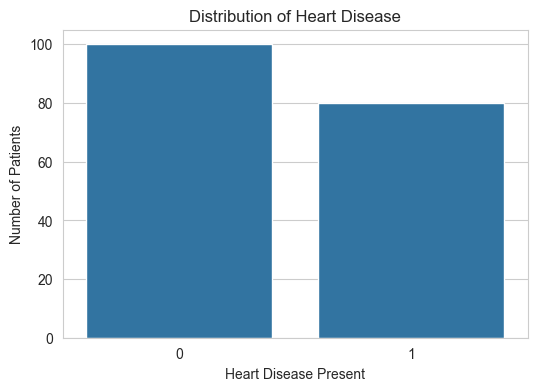

In [18]:
# Count Plot of Target Variable

plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease_present', data=df)

plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease Present')
plt.ylabel('Number of Patients')

plt.show()

In [19]:
# Observation:
# The dataset is looking balanced.
# There are slightly more patients without heart disease than with heart disease, but there is no severe class imbalance.

### Histogram of Numerical Features


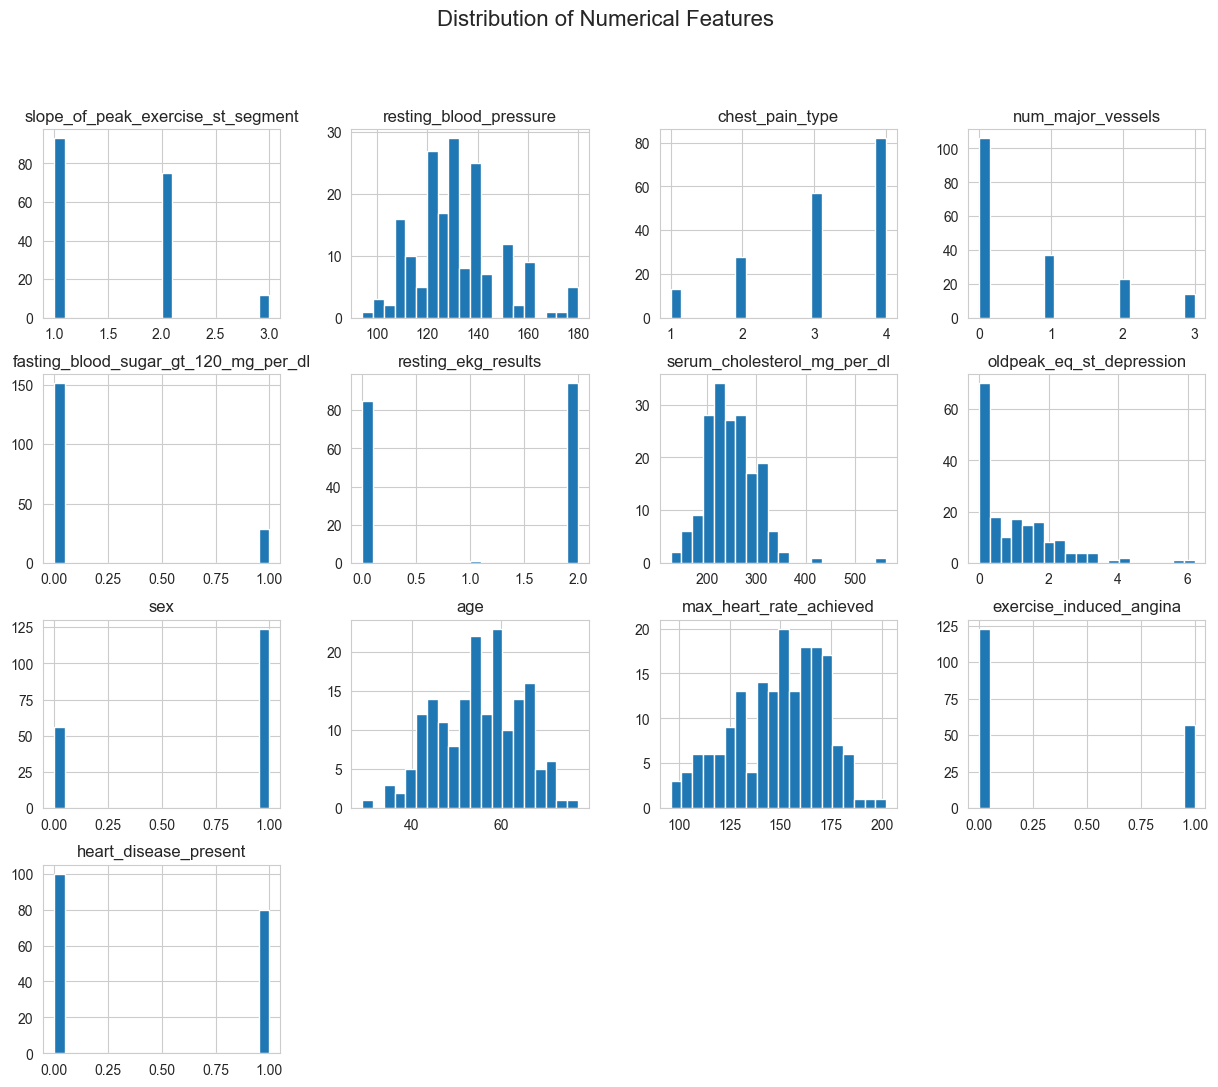

In [20]:
# Histogram of Numerical Features

df.hist(figsize=(15,12), bins=20)

plt.suptitle('Distribution of Numerical Features', fontsize=16)

plt.show()

In [21]:
### Observation

# - Most patients are between 45 and 60 years of age.
# - Serum cholesterol and oldpeak show a right-skewed distribution and may contain outliers.
#- Binary features have only two categories (0 and 1), which is expected.
#- Most numerical features appear suitable for further analysis and model building.

#### Box Plot (Outlier Detection)

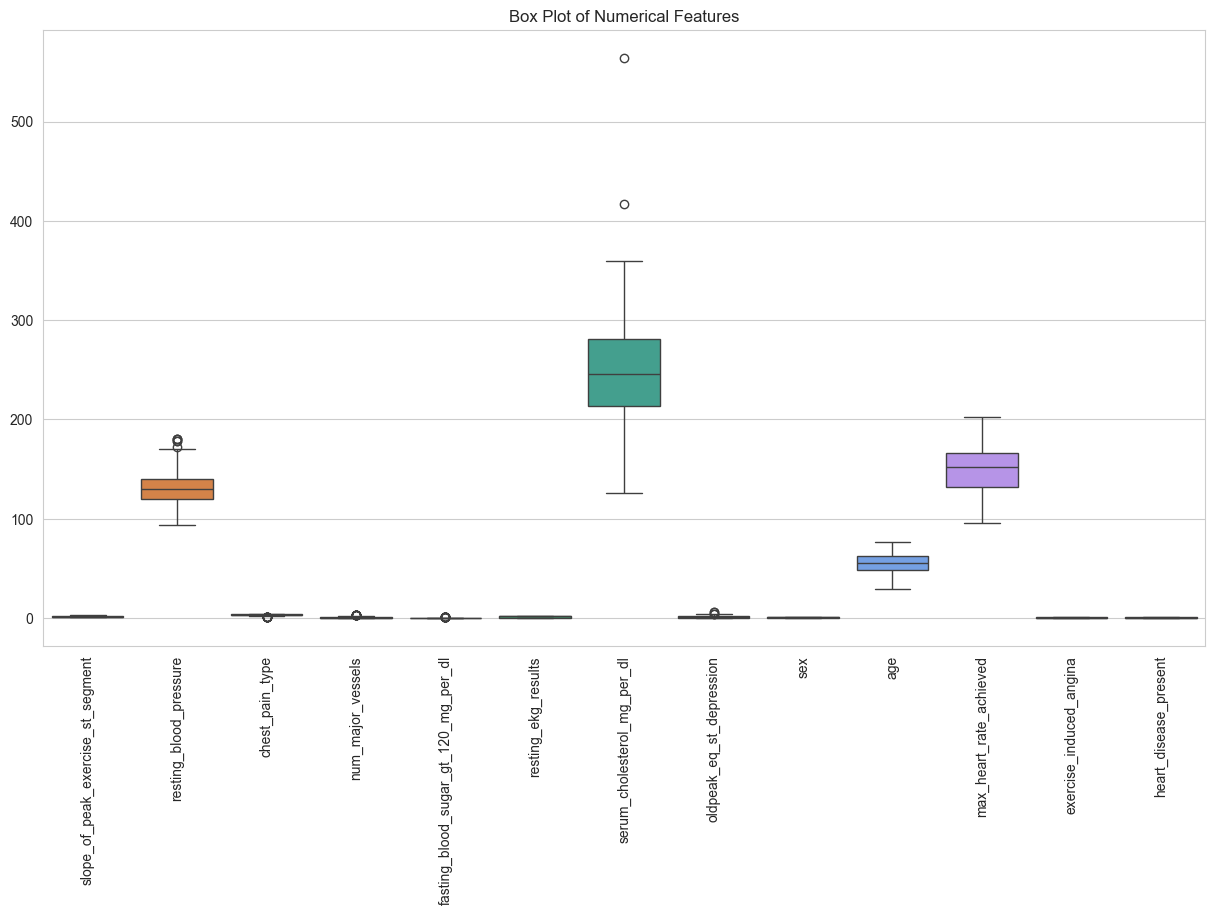

In [22]:
# Box Plot for Numerical Features

plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.title("Box Plot of Numerical Features")

plt.xticks(rotation=90)

plt.show()

In [23]:
# Serum cholesterol contains a few high-value outliers
# Resting blood pressure and oldpeak also show some potential outliers.
# Age does not exhibit significant outliers.
# Most binary and categorical features do not show meaningful box plot patterns because they contain only a few discrete values.

#### Correlation Heatmap

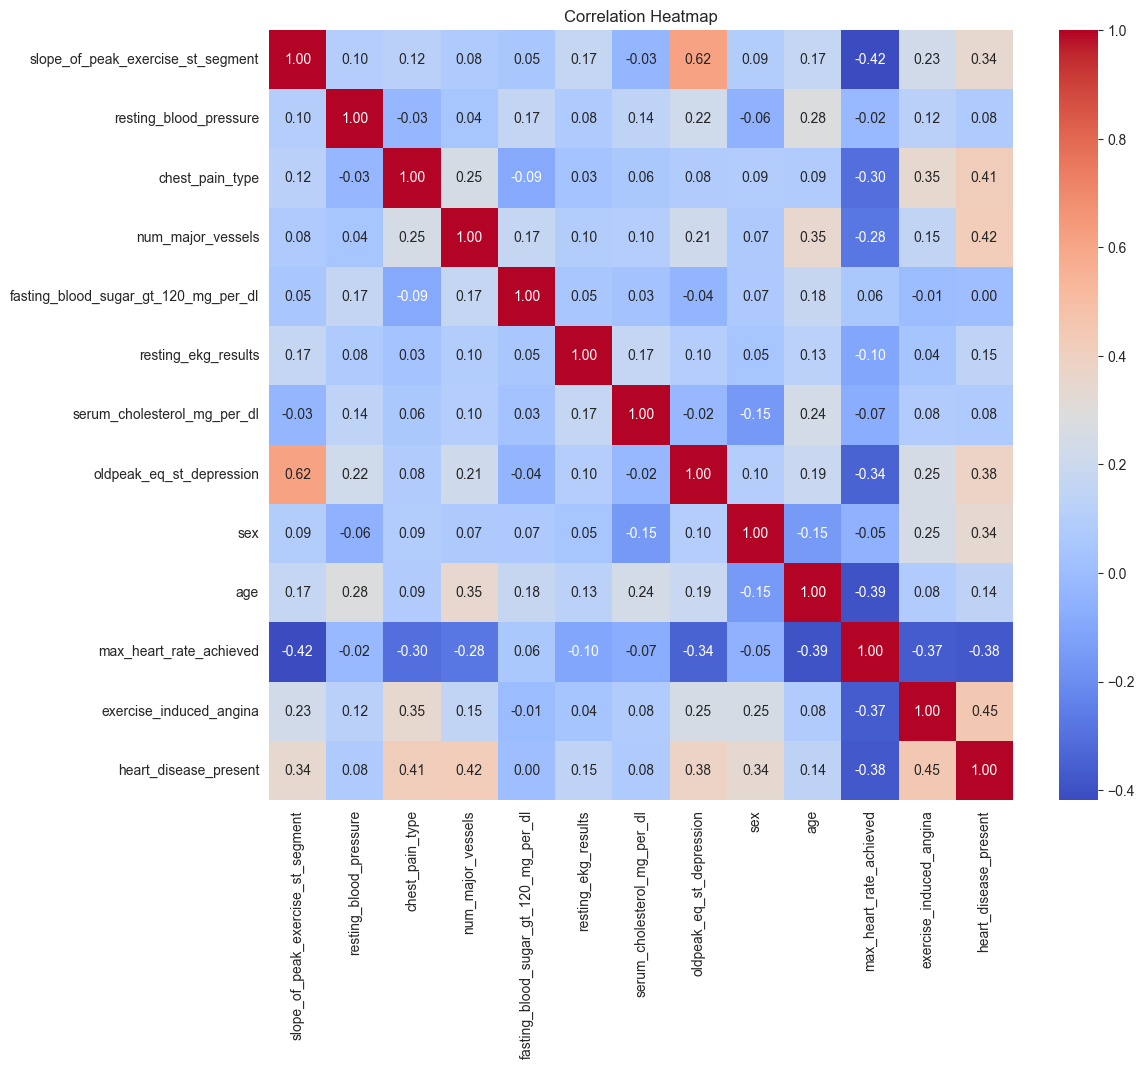

In [24]:
# Correlation Heatmap

plt.figure(figsize=(12,10))

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

In [25]:
# The heatmap shows the corelation between all features
# Correlation values range from:
# +1 = Strong positive correlation
# 0 = No correlation
# -1 = Strong negative correlation

In [26]:
# - The strongest positive correlation with heart disease is observed for thal_reversible_defect, followed by exercise_induced_angina, num_major_vessels, chest_pain_type, oldpeak_eq_st_depression, and slope_of_peak_exercise_st_segment.
# - The strongest negative correlations are observed for thal_normal and max_heart_rate_achieved.
# - Serum cholesterol, fasting blood sugar, and resting ECG results show weak correlation with the target variable.
# - The heatmap helps identify important features that may contribute to heart disease prediction.


In [27]:
# Preprocessing
df['thal'].unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

## Preprocessing

In [28]:
# Preprocessing
# dropping unnecessary columns
df=df.drop('patient_id',axis=1)

In [29]:
df.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [30]:
# One Hot Encoding thal
df=pd.get_dummies(df,columns=['thal'],drop_first=True)


In [31]:
df[['thal_normal', 'thal_reversible_defect']] = df[['thal_normal', 'thal_reversible_defect']].astype(int)

In [32]:
df.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_normal,thal_reversible_defect
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0,1,0
1,2,110,3,0,0,0,214,1.6,0,54,158,0,0,1,0
2,1,125,4,3,0,2,304,0.0,1,77,162,1,1,1,0
3,1,152,4,0,0,0,223,0.0,1,40,181,0,1,0,1
4,3,178,1,0,0,2,270,4.2,1,59,145,0,0,0,1


## Separating Features and Targets

In [33]:
# Separating Fearures and Target
x=df.drop('heart_disease_present',axis=1)

y=df['heart_disease_present']

In [34]:
x.shape

(180, 14)

In [35]:
y.shape

(180,)

## Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# check the shape
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

# stratify ensures that the proportion of patients with and witout heart disease remains
# similar in both the training and testing datasets

x_train shape: (144, 14)
x_test shape: (36, 14)
y_train shape: (144,)
y_test shape: (36,)


## Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler
# create StandardScaler object
scaler=StandardScaler()

# fit on training data and tranform both datasets
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

# check shapes
print("Scaled x_train shape:",x_train.shape)
print("Scaled x_test:",x_test.shape)


Scaled x_train shape: (144, 14)
Scaled x_test: (36, 14)


## Model Training

### 1 Logistic Regression model

In [38]:
from sklearn.linear_model import LogisticRegression
# Create the model
lr_model=LogisticRegression(random_state=42)

#Train the model
lr_model.fit(x_train_scaled,y_train)

# predict on test data
y_pred_lr=lr_model.predict(x_test_scaled)


### Model Evaluation

In [39]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

accuracy=accuracy_score(y_test,y_pred_lr)
print("Logistic Regression Accuracy:",accuracy )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.8333333333333334

Confusion Matrix:
[[17  3]
 [ 3 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.81      0.81      0.81        16

    accuracy                           0.83        36
   macro avg       0.83      0.83      0.83        36
weighted avg       0.83      0.83      0.83        36



In [40]:
# conclusion-
# For Classification Report-
# The values of Precision,Recall and F1 are well balanced
# indicating that the model performs consistently for both classes
# class 0 -No Heart Disease
# class 1-Heart Disease Present

# for Confusion Matrix-
# Out of 20 healthy patients,the model coreectly identified 17.
# Out of 16 patients with heart disease,the model correctly identified 13.
# Model correctly classified 30 out of 36 patients.

### 2 Decision Tree Model

In [41]:
from sklearn.tree import DecisionTreeClassifier
# Create the Decision Tree model
dt_model=DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(x_train,y_train)

# Predict the model
y_pred_dt=dt_model.predict(x_test)


### Evaluation of Decision Tree model

In [42]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Accuracy
dt_accuracy=accuracy_score(y_test,y_pred_dt)
print("Decision Tree Accuracy:",dt_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_dt))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test,y_pred_dt))

Decision Tree Accuracy: 0.8055555555555556

Confusion Matrix:
[[16  4]
 [ 3 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.81      0.79        16

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.81      0.81      0.81        36



In [43]:
#Conclusion-
# Accuracy=0.8056 that is 80.56% 
# the model correctly predict 29 out of 36 patients

# Confusion matrix-
# 16 healthy patients were correctly identified.
# 13 heart disease patients were correctly identified.
# 4 healthy patients were incorrectly predicted as having heart disease.
# 3 heart disease patients were incorrectly predicted as healthy.

# Classification Report-
# The performance for class 1(Heart Disease) is slightly lower than logistic Regression




In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## Prepare data


patient_id is an identifier, so it is excluded from model features. thal is categorical and is one-hot encoded. The remaining columns are numeric.

In [45]:

values = pd.read_csv("../Data/values.csv")
labels = pd.read_csv("../Data/labels.csv")
df = pd.merge(values, labels, on="patient_id", how="inner")
X = df.drop(columns=["patient_id", "heart_disease_present"])
y = df["heart_disease_present"]


categorical_features = ["thal"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 144
Testing samples: 36


### Build and evaluate exactly 5 models

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


models = {
   
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8889,0.8333,0.9375,0.8824,0.9562
1,Logistic Regression,0.8056,0.7647,0.8125,0.7879,0.9406
2,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9359
3,K-Nearest Neighbors,0.8889,0.8750,0.8750,0.8750,0.9141
4,Decision Tree,0.8056,0.8462,0.6875,0.7586,0.8000


## Detail Evaluation

In [47]:
for name, pipe in fitted_models.items():
    pred = pipe.predict(X_test)
    print("=" * 70)
    print(name)
    print(classification_report(y_test, pred, target_names=["No Heart Disease", "Heart Disease"], zero_division=0))

K-Nearest Neighbors
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.90      0.90        20
   Heart Disease       0.88      0.88      0.88        16

        accuracy                           0.89        36
       macro avg       0.89      0.89      0.89        36
    weighted avg       0.89      0.89      0.89        36

Logistic Regression
                  precision    recall  f1-score   support

No Heart Disease       0.84      0.80      0.82        20
   Heart Disease       0.76      0.81      0.79        16

        accuracy                           0.81        36
       macro avg       0.80      0.81      0.80        36
    weighted avg       0.81      0.81      0.81        36

Decision Tree
                  precision    recall  f1-score   support

No Heart Disease       0.78      0.90      0.84        20
   Heart Disease       0.85      0.69      0.76        16

        accuracy                           0.81        36
       mac

## Compare the five models

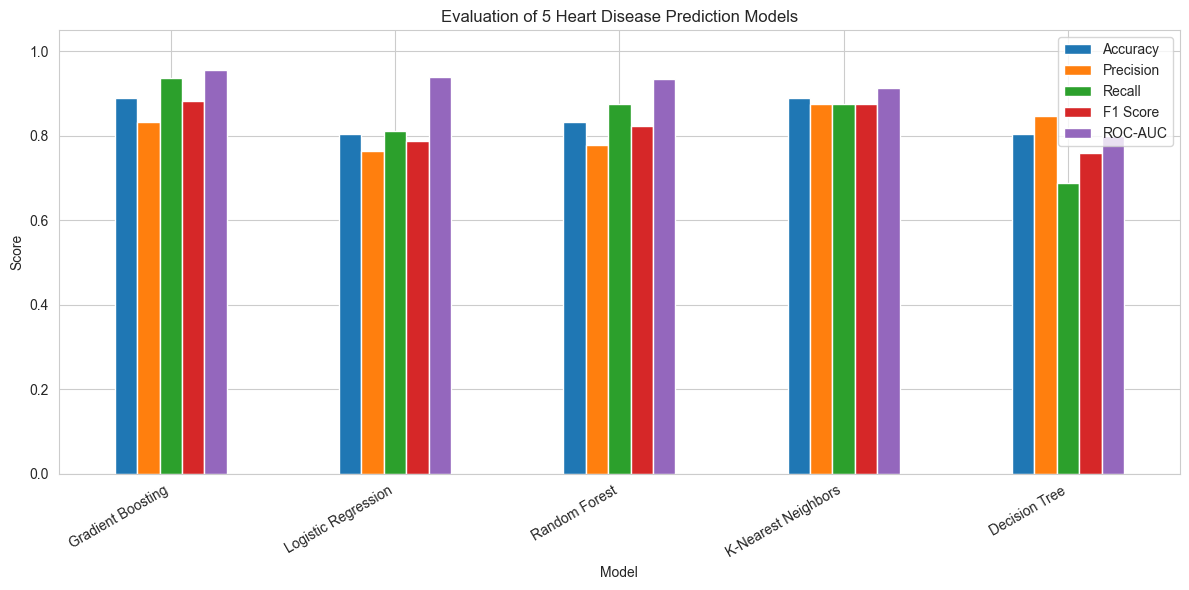

Best model by ROC-AUC: Gradient Boosting
ROC-AUC: 0.9562


In [48]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
ax = results_df.set_index("Model")[metrics].plot(kind="bar", figsize=(12, 6))
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Evaluation of 5 Heart Disease Prediction Models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print("Best model by ROC-AUC:", best_model["Model"])
print("ROC-AUC:", round(best_model["ROC-AUC"], 4))

## Notes




The notebook uses a stratified 80/20 train-test split with random_state=42 for reproducibility.
The five models are Logistic Regression, KNN, Decision Tree, Random Forest, and Gradient Boosting.
The best model is selected by ROC-AUC on the held-out test set.
The project brief asks for multiple-model performance comparison and a production recommendation; this notebook provides that comparison. fileciteturn0file0L47-L54